In [1]:
# =============================================================================
# BAGIAN 1: IMPORT LIBRARY & PENGATURAN AWAL
# =============================================================================
import os
import zipfile
import calendar
import getpass
import cdsapi
import pandas as pd
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import mapping
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Konfigurasi API CDS
url = "https://cds.climate.copernicus.eu/api"

print("\n[KONFIGURASI API CDS]")
print("Silakan masukkan API Key CDS Anda, lalu tekan Enter.")
key = getpass.getpass("API Key: ")

with open('/root/.cdsapirc', 'w') as f:
    f.write(f"url: {url}\nkey: {key}")

print("[INFO] Konfigurasi API berhasil disimpan.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[KONFIGURASI API CDS]
Silakan masukkan API Key CDS Anda, lalu tekan Enter.
API Key: ··········
[INFO] Konfigurasi API berhasil disimpan.


In [2]:
# =============================================================================
# BAGIAN 2: DOWNLOAD & PERSIAPAN DATA (ERA5-LAND)
# =============================================================================
print("\n[PROSES 1] Memulai pengunduhan dan pemeriksaan data...")

nc_filename = "jambi_era5_land_2010_2020.nc"
final_data_path = nc_filename

# Cek keberadaan file
file_exists = os.path.exists(nc_filename)
file_valid = False

if file_exists:
    # Cek ukuran file untuk memastikan tidak korup (minimal 1KB)
    if os.path.getsize(nc_filename) > 1000:
        file_valid = True
        print("[INFO] File data ditemukan. Melewati proses unduh.")
    else:
        print("[INFO] File ditemukan tetapi ukuran terlalu kecil (korup). Menghapus file lama...")
        os.remove(nc_filename)

if not file_valid:
    print("[INFO] Mengunduh data dari Climate Data Store...")
    try:
        c = cdsapi.Client()
        c.retrieve(
            'reanalysis-era5-land-monthly-means',
            {
                'product_type': 'monthly_averaged_reanalysis',
                'variable': ['2m_temperature', 'total_precipitation'],
                'year': [str(x) for x in range(2010, 2021)],
                'month': [f"{x:02d}" for x in range(1, 13)],
                'time': '00:00',
                'area': [0, 101, -3, 105], # Bounding Box Jambi
                'format': 'netcdf',
            },
            nc_filename)
        print("[SUKSES] Pengunduhan selesai.")
    except Exception as e:
        print(f"[ERROR] Gagal mengunduh data: {e}")
        raise

# Penanganan File ZIP (Jika CDS mengirimkan ZIP alih-alih NetCDF murni)
if zipfile.is_zipfile(nc_filename):
    print("[INFO] File terdeteksi sebagai ZIP. Mengekstrak...")
    with zipfile.ZipFile(nc_filename, 'r') as zip_ref:
        zip_ref.extractall(".")
        extracted_files = zip_ref.namelist()

        # Mencari file .nc hasil ekstraksi
        for f in extracted_files:
            if f.endswith('.nc'):
                final_data_path = f
                print(f"[INFO] Menggunakan file hasil ekstrak: {final_data_path}")
                break


[PROSES 1] Memulai pengunduhan dan pemeriksaan data...
[INFO] Mengunduh data dari Climate Data Store...


2026-02-18 23:59:12,958 INFO Request ID is ead0563d-c79e-4c37-93a9-a96ffcaf2afe
INFO:ecmwf.datastores.legacy_client:Request ID is ead0563d-c79e-4c37-93a9-a96ffcaf2afe
2026-02-18 23:59:13,053 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-02-18 23:59:26,522 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-02-18 23:59:34,267 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


244950ef3c68d94b0a633633dd5f562d.zip:   0%|          | 0.00/726k [00:00<?, ?B/s]

[SUKSES] Pengunduhan selesai.
[INFO] File terdeteksi sebagai ZIP. Mengekstrak...
[INFO] Menggunakan file hasil ekstrak: data_stream-moda.nc


In [3]:
# =============================================================================
# BAGIAN 3: PEMOTONGAN SPASIAL (CLIPPING)
# =============================================================================
print("\n[PROSES 2] Melakukan clipping data sesuai batas administrasi...")

# Path Shapefile (Sesuaikan jika ada perubahan folder)
ADMIN_PATH = '/content/drive/My Drive/Colab Notebooks/Skripsi/Batas Adm Jambi/Adm_Jambi_Prov.shp'

try:
    # Membuka file NetCDF
    ds = xr.open_dataset(final_data_path, engine='netcdf4')
    ds = ds.rio.write_crs("EPSG:4326")

    # Membuka Shapefile
    gdf = gpd.read_file(ADMIN_PATH)
    if gdf.crs != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")

    # Proses Clipping
    clipped_ds = ds.rio.clip(gdf.geometry.apply(mapping), gdf.crs, drop=True, all_touched=True)
    print("[SUKSES] Clipping data berhasil.")

except Exception as e:
    print(f"[ERROR] Terjadi kesalahan pada proses spasial: {e}")
    print("Saran: Periksa path shapefile dan pastikan file .shp, .shx, .dbf lengkap.")
    raise


[PROSES 2] Melakukan clipping data sesuai batas administrasi...
[SUKSES] Clipping data berhasil.


In [4]:
# =============================================================================
# BAGIAN 4: PENGOLAHAN DATA STATISTIK
# =============================================================================
print("\n[PROSES 3] Menghitung statistik klimatologi...")

# Rata-rata spasial (seluruh pixel menjadi satu nilai per waktu)
df_mean = clipped_ds.mean(dim=["latitude", "longitude"]).to_dataframe().reset_index()

# Normalisasi nama kolom waktu
if 'valid_time' in df_mean.columns:
    df_mean = df_mean.rename(columns={'valid_time': 'time'})

if 'time' not in df_mean.columns:
    raise ValueError("[ERROR] Kolom waktu tidak ditemukan dalam dataset.")

# Filter kolom yang dibutuhkan
df_mean = df_mean[['time', 't2m', 'tp']]

# Konversi Satuan
# 1. Suhu: Kelvin ke Celcius
df_mean['Suhu_C'] = df_mean['t2m'] - 273.15

# 2. Hujan: m/day ke mm/month
def hitung_hujan_bulanan(row):
    ts = row['time'] if isinstance(row['time'], pd.Timestamp) else pd.to_datetime(row['time'])
    days_in_month = calendar.monthrange(ts.year, ts.month)[1]
    return row['tp'] * 1000 * days_in_month

df_mean['CH_mm'] = df_mean.apply(hitung_hujan_bulanan, axis=1)

# Agregasi Bulanan (Pola Musiman)
df_mean['Bulan_Angka'] = df_mean['time'].dt.month
klimatogram = df_mean.groupby('Bulan_Angka').agg({
    'CH_mm': 'mean',
    'Suhu_C': 'mean'
}).reset_index()

# Tambah Label Bulan
nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
              'Jul', 'Agt', 'Sep', 'Okt', 'Nov', 'Des']
klimatogram['Nama_Bulan'] = nama_bulan

print("[SUKSES] Pengolahan data selesai.")


[PROSES 3] Menghitung statistik klimatologi...
[SUKSES] Pengolahan data selesai.



[PROSES 4] Membuat visualisasi grafik...


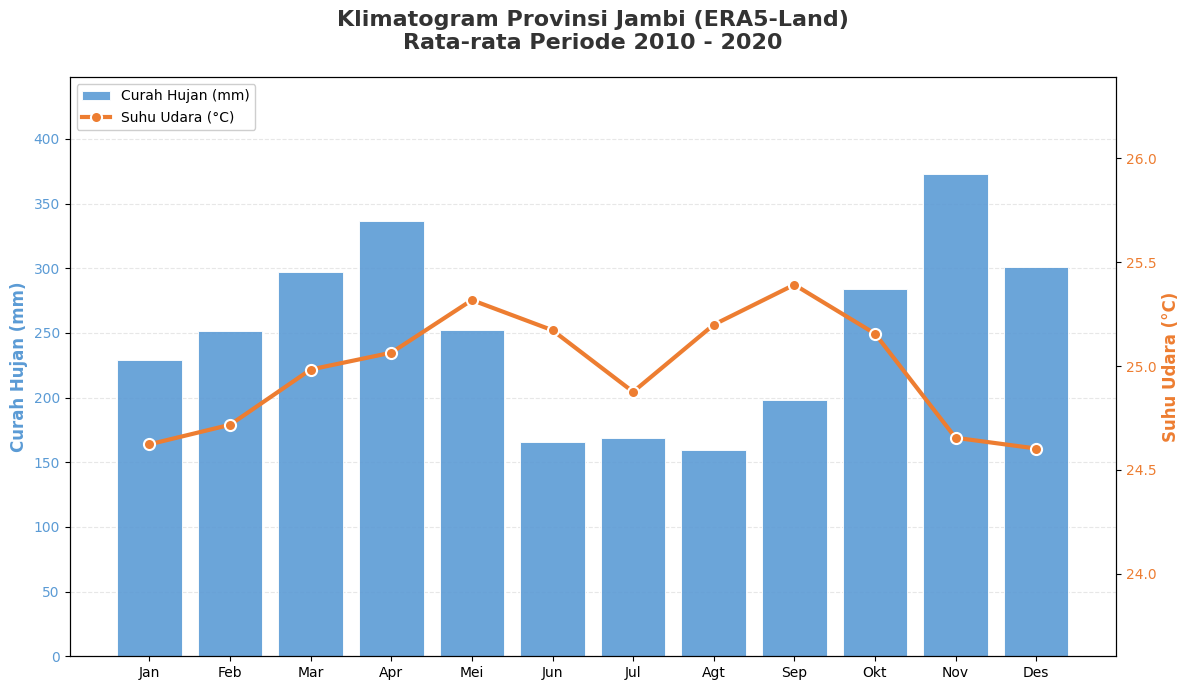

[SELESAI] Grafik telah disimpan sebagai: klimatogram_jambi_era5.png


In [6]:
# =============================================================================
# BAGIAN 5: VISUALISASI GRAFIK
# =============================================================================
print("\n[PROSES 4] Membuat visualisasi grafik...")

# Pengaturan Font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Warna
warna_hujan = '#5B9BD5'
warna_suhu  = '#ED7D31'

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Curah Hujan (Bar Chart)
ax1.bar(klimatogram['Nama_Bulan'], klimatogram['CH_mm'],
        color=warna_hujan, alpha=0.9, label='Curah Hujan (mm)',
        zorder=2, edgecolor='white', linewidth=0.7)

ax1.set_ylabel('Curah Hujan (mm)', fontsize=12, fontweight='bold', color=warna_hujan)
ax1.tick_params(axis='y', labelcolor=warna_hujan, labelsize=10)
ax1.set_ylim(0, klimatogram['CH_mm'].max() * 1.2) # Margin atas 20%
ax1.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# Plot Suhu Udara (Line Chart)
ax2 = ax1.twinx()
ax2.plot(klimatogram['Nama_Bulan'], klimatogram['Suhu_C'],
         color=warna_suhu, marker='o', linewidth=3, markersize=8,
         label='Suhu Udara (°C)', zorder=3,
         markeredgecolor='white', markeredgewidth=1.5)

ax2.set_ylabel('Suhu Udara (°C)', fontsize=12, fontweight='bold', color=warna_suhu)
ax2.tick_params(axis='y', labelcolor=warna_suhu, labelsize=10)

# Pengaturan Skala Suhu
min_suhu = klimatogram['Suhu_C'].min()
max_suhu = klimatogram['Suhu_C'].max()
ax2.set_ylim(min_suhu - 1, max_suhu + 1)

# Judul dan Legenda
plt.title('Klimatogram Provinsi Jambi (ERA5-Land)\nRata-rata Periode 2010 - 2020',
          fontsize=16, pad=20, fontweight='bold', color='#333333')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left',
           frameon=True, fancybox=True, framealpha=0.95, edgecolor='#cccccc')

plt.tight_layout()
filename_output = 'klimatogram_jambi_era5.png'
plt.savefig(filename_output, dpi=300)
plt.show()

print(f"[SELESAI] Grafik telah disimpan sebagai: {filename_output}")